# 04 · Extract Real ECG Waveforms
## ICU Virtual Patient Feed — WFDB → `.npy` for all 66 ECG records

This notebook reads each real 12-lead ECG record from the MIMIC-IV-ECG WFDB files,
extracts Lead II (and all 12 leads), and saves them as `.npy` arrays that the streaming
engine can load at runtime.

### Outputs

```
data/processed/
├── ecg_waveforms/
│   ├── p16179553_s12345678_lead2.npy    shape (5000,)    float32  500 Hz × 10 s
│   ├── p16179553_s12345678_all12.npy    shape (12, 5000) float32
│   └── ...  (~66 records × 2 files each)
└── ecg_index/
    ├── ecg_index_16179553.json          metadata + file paths per ECG study
    └── ...  (one per patient)
```

### What these files are used for

The streaming engine (engine.py, built next) calls `ECGPlayer.load_ecg(lead2_path)` at each
ECG timestamp in the timeline. The `ecg_lead2_file` column in the patient parquets already
contains these paths — this notebook creates the actual files they point to.

### Prerequisites

`wfdb` must be installed: `pip install wfdb`
The MIMIC-IV-ECG `files/` directory must be on disk (it's the large folder with `.hea`/`.dat` files).


In [10]:
import pandas as pd
import numpy as np
import json
import pickle
from pathlib import Path

try:
    import wfdb
    print(f"✅ wfdb {wfdb.__version__} available")
except ImportError:
    raise ImportError("wfdb not installed. Run: pip install wfdb  then restart kernel.")

pd.set_option("display.width", 120)


✅ wfdb 4.3.1 available


In [11]:
CURRENT_DIR  = Path.cwd()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "scripts" else CURRENT_DIR

ECG_ROOT       = PROJECT_ROOT / "data" / "external" / "mimic-iv-ecg"
CACHE_DIR      = PROJECT_ROOT / "data" / "cache"
WAVEFORM_DIR   = PROJECT_ROOT / "data" / "processed" / "ecg_waveforms"
ECG_INDEX_DIR  = PROJECT_ROOT / "data" / "processed" / "ecg_index"
TIMELINE_DIR   = PROJECT_ROOT / "data" / "processed" / "patient_timelines"

WAVEFORM_DIR.mkdir(parents=True, exist_ok=True)
ECG_INDEX_DIR.mkdir(parents=True, exist_ok=True)

FINAL_PATIENTS = [
    {"subject_id": 16179553, "stay_id": 38224135, "hadm_id": 25052613,
     "label": "CVICU — mitral valve replacement + ECMO + cardiogenic shock"},
    {"subject_id": 17520318, "stay_id": 30682249, "hadm_id": 23431795,
     "label": "CVICU — CABG + AVR + septic shock, 7 drugs"},
    {"subject_id": 13269747, "stay_id": 31792549, "hadm_id": 25584074,
     "label": "CCU — AFib under rate control, 16 ECGs"},
    {"subject_id": 13408370, "stay_id": 30547595, "hadm_id": 27107260,
     "label": "CCU — anterior MI + VF arrest + AICD, 28 ECGs"},
    {"subject_id": 15906662, "stay_id": 36609534, "hadm_id": 24072687,
     "label": "CVICU — AMI + multi-vessel CABG + cardiogenic shock, 7 drugs"},
]

# Sanity check
print(f"ECG_ROOT: {ECG_ROOT}")
print(f"  files/ exists:          {'✅' if (ECG_ROOT/'files').exists() else '❌ MISSING'}")
print(f"  record_list.csv exists: {'✅' if (ECG_ROOT/'record_list.csv').exists() else '❌ MISSING'}")
print(f"Waveform output dir:  {WAVEFORM_DIR}")
print(f"ECG index output dir: {ECG_INDEX_DIR}")


ECG_ROOT: c:\Users\dalia\OneDrive\Dokumente\Praktikum2026\SASISimulator\data\external\mimic-iv-ecg
  files/ exists:          ✅
  record_list.csv exists: ✅
Waveform output dir:  c:\Users\dalia\OneDrive\Dokumente\Praktikum2026\SASISimulator\data\processed\ecg_waveforms
ECG index output dir: c:\Users\dalia\OneDrive\Dokumente\Praktikum2026\SASISimulator\data\processed\ecg_index


---
## Section 1 · Load ECG record table

We load the ECG metadata from the notebook 03 cache (already filtered to our 5 patients).
This gives us: `study_id`, `subject_id`, `ecg_time`, `path` (the WFDB directory path),
and all machine measurement columns.

The `path` column is the key: it contains the relative path to the WFDB record directory,
e.g. `files/p16/p16179553/s12345678/`. Appending the study_id gives the full record path
that `wfdb.rdrecord()` expects.


In [12]:
# Load from nb03 cache
ecg_cache = CACHE_DIR / "nb03_ecgs.pkl"
if not ecg_cache.exists():
    raise FileNotFoundError(
        f"nb03_ecgs.pkl not found at {ecg_cache}\n"
        "Run notebook 03 Section 2 first to build this cache."
    )

with open(ecg_cache, "rb") as f:
    import pickle
    ecgs = pickle.load(f)

print(f"Loaded {len(ecgs)} ECG records across {ecgs['subject_id'].nunique()} patients")
print(f"Columns: {ecgs.columns.tolist()}")
print()

# Check path column format (we need it to construct wfdb paths)
print("Example path values:")
print(ecgs[["subject_id","study_id","ecg_time","path"]].head(6).to_string(index=False))

print()
print("Records per patient:")
print(ecgs.groupby("subject_id")["study_id"].count().to_string())


Loaded 98 ECG records across 5 patients
Columns: ['subject_id', 'study_id', 'file_name', 'ecg_time', 'path', 'cart_id', 'report_0', 'report_1', 'report_2', 'report_3', 'report_4', 'report_5', 'report_6', 'report_7', 'report_8', 'report_9', 'report_10', 'report_11', 'report_12', 'report_13', 'report_14', 'report_15', 'report_16', 'report_17', 'bandwidth', 'filtering', 'rr_interval', 'p_onset', 'p_end', 'qrs_onset', 'qrs_end', 't_end', 'p_axis', 'qrs_axis', 't_axis', 'heart_rate', 'pr_interval', 'qrs_duration', 'qt_interval', 'qtc_interval', 'report']

Example path values:
 subject_id  study_id            ecg_time                                     path
   13269747  49153280 2159-07-24 10:18:00 files/p1326/p13269747/s49153280/49153280
   13269747  42809919 2159-07-31 10:41:00 files/p1326/p13269747/s42809919/42809919
   13269747  47238297 2160-06-24 08:36:00 files/p1326/p13269747/s47238297/47238297
   13269747  48462082 2160-06-24 08:44:00 files/p1326/p13269747/s48462082/48462082
   1326

---
## Section 2 · WFDB path helper + waveform extraction functions

### MIMIC-IV-ECG file structure
```
mimic-iv-ecg/
  files/
    p16/                     ← first 2 digits of subject_id
      p16179553/             ← full subject_id with p prefix
        s12345678/           ← study directory with s prefix
          12345678.hea       ← WFDB header
          12345678.dat       ← WFDB signal data
```

`wfdb.rdrecord()` takes the path WITHOUT the extension:
`wfdb.rdrecord("…/files/p16/p16179553/s12345678/12345678")`

The `path` column in `record_list.csv` already gives us everything up to the study directory.
We just append the numeric `study_id` to get the record name.

### Normalisation strategy
WFDB's `.p_signal` already converts raw ADC counts to physical units (mV) using the
gain/baseline stored in the `.hea` header — no manual gain correction needed.
We clip at ±5 mV to remove pressure-flush artefacts, then cast to float32.


In [13]:
def get_wfdb_record_path(ecg_root: Path, path_col: str) -> str:
    """
    Build the full record path for wfdb.rdrecord().

    In MIMIC-IV-ECG, the 'path' column in record_list.csv already contains
    the full relative path INCLUDING the record filename, e.g.:
        files/p1326/p13269747/s49153280/49153280
    We just prepend ECG_ROOT — no need to append study_id again.
    """
    return str(ecg_root / path_col)


def extract_waveform(record_path: str):
    """
    Load a WFDB record and return (lead2_array, all12_array, fs, sig_names).
    Returns None if the file doesn't exist or can't be read.

    lead2_array: float32 (N,)        — Lead II only, mV, clipped ±5 mV
    all12_array: float32 (12, N)     — all leads in standard order
    fs:          int                 — sampling frequency (expected: 500)
    sig_names:   list[str]           — signal names from header
    """
    try:
        rec = wfdb.rdrecord(record_path)
    except Exception as e:
        return None, None, None, None, str(e)

    fs   = rec.fs
    sigs = rec.p_signal  # shape (N_samples, N_leads), physical units (mV)

    if sigs is None or np.all(np.isnan(sigs)):
        return None, None, fs, rec.sig_name, "all-NaN signal"

    # Lead II: look for exact match first, then partial
    sig_names = list(rec.sig_name) if rec.sig_name else []
    lead2_idx = None
    for name in ["II", "ii"]:
        if name in sig_names:
            lead2_idx = sig_names.index(name)
            break

    if lead2_idx is None:
        # Fallback: use first available lead and warn
        lead2_idx = 0
        lead2_name = sig_names[0] if sig_names else "unknown"
        error_note = f"Lead II not found, using {lead2_name}"
    else:
        error_note = None

    # Extract + normalise
    lead2 = sigs[:, lead2_idx].astype("float32")
    lead2 = np.clip(lead2, -5.0, 5.0)   # clip artefacts
    lead2 = np.nan_to_num(lead2, nan=0.0)

    # All 12 leads (or however many are present)
    all12 = sigs.T.astype("float32")                  # (N_leads, N_samples)
    all12 = np.clip(all12, -5.0, 5.0)
    all12 = np.nan_to_num(all12, nan=0.0)

    return lead2, all12, fs, sig_names, error_note


def expected_lead2_path(subject_id: int, study_id) -> Path:
    """Convention used in patient parquets — must match nb03 exactly."""
    return WAVEFORM_DIR / f"p{subject_id}_s{study_id}_lead2.npy"

def expected_all12_path(subject_id: int, study_id) -> Path:
    return WAVEFORM_DIR / f"p{subject_id}_s{study_id}_all12.npy"


print("✅ Helper functions defined")
print()
print("Quick path construction test:")
sample = ecgs.iloc[0]
test_path = get_wfdb_record_path(ECG_ROOT, sample["path"])
print(f"  study_id:    {sample['study_id']}")
print(f"  path col:    {sample['path']}")
print(f"  record path: {test_path}")
print(f"  .hea exists: {'✅' if Path(test_path + '.hea').exists() else '❌ NOT FOUND'}")


✅ Helper functions defined

Quick path construction test:
  study_id:    49153280
  path col:    files/p1326/p13269747/s49153280/49153280
  record path: c:\Users\dalia\OneDrive\Dokumente\Praktikum2026\SASISimulator\data\external\mimic-iv-ecg\files\p1326\p13269747\s49153280\49153280
  .hea exists: ✅


---
## Section 3 · Extract waveforms + build ECG index

For each of the 5 patients, iterates over all ECG studies in the window,
loads the WFDB record, saves Lead II and all-12-leads `.npy` files,
and builds a rich metadata dict for the ECG index JSON.

Files that already exist on disk are skipped — safe to re-run if interrupted.


In [14]:
# Füge diese Zelle VOR Section 3 ein (einmalig laden):
with open(CACHE_DIR / "nb03_icustays.pkl", "rb") as f:
    stays_c = pickle.load(f)

In [15]:
all_results = {}   # subject_id → list of per-study result dicts

for patient in FINAL_PATIENTS:
    sid   = patient["subject_id"]
    label = patient["label"]

    patient_ecgs = ecgs[ecgs["subject_id"] == sid].copy()

    # Filter to ±48h around ICU stay (same window used in timeline building)
    stay = stays_c[stays_c["stay_id"] == patient["stay_id"]].iloc[0]
    patient_ecgs = patient_ecgs[
    (patient_ecgs["ecg_time"] >= stay["intime"] - pd.Timedelta(hours=48)) &
    (patient_ecgs["ecg_time"] <= stay["outtime"] + pd.Timedelta(hours=48))
    ].copy()
    # patient_ecgs = patient_ecgs.sort_values("ecg_time").reset_index(drop=True)

    print(f"\n{'─'*60}")
    print(f"subject {sid}  |  {len(patient_ecgs)} ECGs  |  {label}")
    print(f"{'─'*60}")

    results = []
    ok_count = fail_count = skip_count = 0

    for _, row in patient_ecgs.iterrows():
        study_id  = row["study_id"]
        ecg_time  = row["ecg_time"]
        path_col  = row.get("path", "")

        lead2_path = expected_lead2_path(sid, study_id)
        all12_path = expected_all12_path(sid, study_id)

        # Skip if already extracted
        if lead2_path.exists() and all12_path.exists():
            skip_count += 1
            status = "⏭  skip"
            error_note = None
            fs = 500
            sig_names = []
        else:
            record_path = get_wfdb_record_path(ECG_ROOT, path_col)
            lead2, all12, fs, sig_names, error_note = extract_waveform(record_path)

            if lead2 is None:
                fail_count += 1
                status = f"❌ FAIL"
                # Store result with null file paths — timeline will fall back to synthetic
            else:
                np.save(str(lead2_path), lead2)
                np.save(str(all12_path), all12)
                ok_count += 1
                status = "✅ OK  "

        print(f"  {status}  study {study_id}  {str(ecg_time)[:16]}"
              + (f"  ⚠️  {error_note}" if error_note else "")
              + (f"  fs={fs}" if fs and fs != 500 else "")
              + (f"  leads={sig_names}" if sig_names and lead2_path.exists() else ""))

        # Build the index entry regardless of success
        entry = {
            "study_id":          str(study_id),
            "ecg_time":          str(ecg_time),
            "subject_id":        int(sid),
            "lead2_file":        str(lead2_path.relative_to(PROJECT_ROOT))
                                 if lead2_path.exists() else None,
            "all12_file":        str(all12_path.relative_to(PROJECT_ROOT))
                                 if all12_path.exists() else None,
            "fs":                int(fs) if fs else 500,
            "n_samples":         int(np.load(str(lead2_path)).shape[0])
                                 if lead2_path.exists() else None,
            "extraction_ok":     lead2_path.exists(),
            "extraction_error":  error_note,
            # Machine measurement columns (from machine_measurements.csv via ecgs cache)
            "machine_rhythm":    str(row["report"])     if "report"       in row.index and pd.notna(row["report"])       else None,
            "machine_hr":        float(row["heart_rate"])  if "heart_rate"  in row.index and pd.notna(row["heart_rate"])  else None,
            "machine_pr_ms":     float(row["pr_interval"]) if "pr_interval" in row.index and pd.notna(row["pr_interval"]) else None,
            "machine_qrs_ms":    float(row["qrs_duration"])if "qrs_duration"in row.index and pd.notna(row["qrs_duration"])else None,
            "machine_qt_ms":     float(row["qt_interval"]) if "qt_interval" in row.index and pd.notna(row["qt_interval"]) else None,
            "machine_qtc_ms":    float(row["qtc_interval"])if "qtc_interval"in row.index and pd.notna(row["qtc_interval"])else None,
        }
        results.append(entry)

    all_results[sid] = results
    print(f"  → ✅ {ok_count}  ⏭  {skip_count}  ❌ {fail_count}  "
          f"(total {len(results)})")

print(f"\n{'='*60}")
total_ok = sum(sum(1 for e in v if e['extraction_ok']) for v in all_results.values())
total    = sum(len(v) for v in all_results.values())
print(f"Extraction complete: {total_ok}/{total} records extracted successfully")



────────────────────────────────────────────────────────────
subject 16179553  |  7 ECGs  |  CVICU — mitral valve replacement + ECMO + cardiogenic shock
────────────────────────────────────────────────────────────
  ⏭  skip  study 44394475  2162-10-31 08:35
  ⏭  skip  study 42376708  2162-11-02 05:19
  ⏭  skip  study 43868728  2162-11-03 19:11
  ⏭  skip  study 42061297  2162-11-03 20:59
  ⏭  skip  study 49803061  2162-11-03 21:03
  ⏭  skip  study 49250457  2162-11-03 21:04
  ⏭  skip  study 42157758  2162-11-12 15:39
  → ✅ 0  ⏭  7  ❌ 0  (total 7)

────────────────────────────────────────────────────────────
subject 17520318  |  7 ECGs  |  CVICU — CABG + AVR + septic shock, 7 drugs
────────────────────────────────────────────────────────────
  ⏭  skip  study 48660583  2170-03-01 02:59
  ⏭  skip  study 47086339  2170-03-02 04:21
  ⏭  skip  study 48017535  2170-03-04 22:47
  ⏭  skip  study 44261241  2170-03-04 22:48
  ⏭  skip  study 47993507  2170-03-06 08:02
  ⏭  skip  study 41922966  21

---
## Section 4 · Save ECG index JSON files

One JSON file per patient. The streaming engine loads this at startup to know
which waveform file to play at each point in the timeline.


In [16]:
for patient in FINAL_PATIENTS:
    sid = patient["subject_id"]
    if sid not in all_results:
        print(f"⚠️  No results for subject {sid} — skipping")
        continue

    index_path = ECG_INDEX_DIR / f"ecg_index_{sid}.json"
    with open(index_path, "w") as f:
        json.dump(all_results[sid], f, indent=2, default=str)

    ok = sum(1 for e in all_results[sid] if e["extraction_ok"])
    print(f"  ✅ ecg_index_{sid}.json  "
          f"({len(all_results[sid])} records, {ok} with waveforms, "
          f"{index_path.stat().st_size/1024:.1f} KB)")

print()
print("Sample entry from first patient:")
first_sid = FINAL_PATIENTS[0]["subject_id"]
sample_entry = all_results[first_sid][0]
print(json.dumps(sample_entry, indent=2, default=str))


  ✅ ecg_index_16179553.json  (7 records, 7 with waveforms, 4.7 KB)
  ✅ ecg_index_17520318.json  (7 records, 7 with waveforms, 5.0 KB)
  ✅ ecg_index_13269747.json  (16 records, 16 with waveforms, 11.1 KB)
  ✅ ecg_index_13408370.json  (28 records, 28 with waveforms, 20.2 KB)
  ✅ ecg_index_15906662.json  (8 records, 8 with waveforms, 5.7 KB)

Sample entry from first patient:
{
  "study_id": "44394475",
  "ecg_time": "2162-10-31 08:35:00",
  "subject_id": 16179553,
  "lead2_file": "data\\processed\\ecg_waveforms\\p16179553_s44394475_lead2.npy",
  "all12_file": "data\\processed\\ecg_waveforms\\p16179553_s44394475_all12.npy",
  "fs": 500,
  "n_samples": 5000,
  "extraction_ok": true,
  "extraction_error": null,
  "machine_rhythm": "Sinus rhythm; Possible left atrial abnormality; Extensive ST-T changes suggest myocardial injury/ischemia; Abnormal ECG",
  "machine_hr": 88.10572687224669,
  "machine_pr_ms": 164.0,
  "machine_qrs_ms": 86.0,
  "machine_qt_ms": 362.0,
  "machine_qtc_ms": 438.66705

---
## Section 5 · Spot-check: plot first and last ECG per patient

For each patient, plots the first and last successfully extracted Lead II waveform.
This confirms: correct sampling rate, plausible amplitude (~0.5–2 mV), no all-zero
or all-NaN signal, and that the waveform actually looks like an ECG.


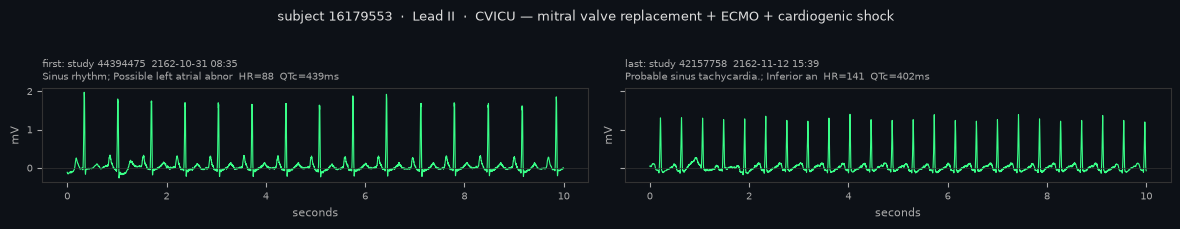

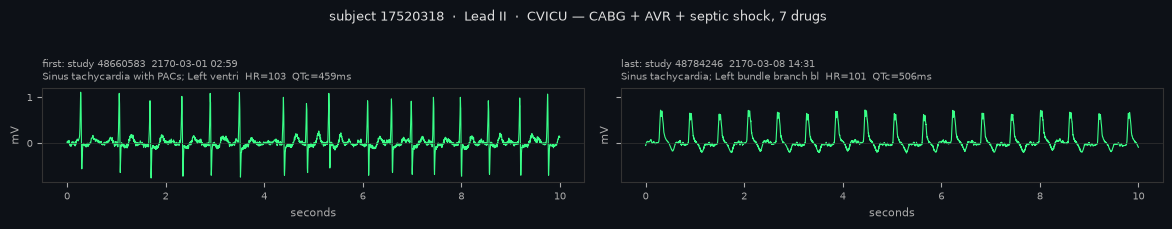

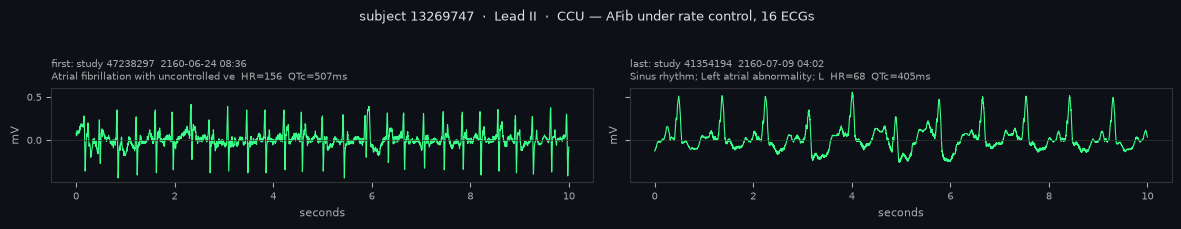

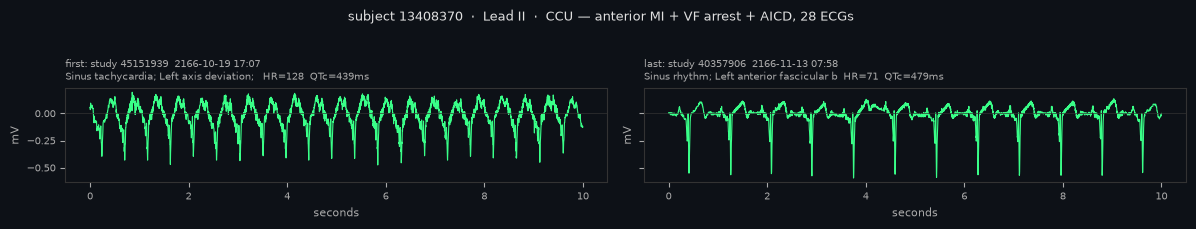

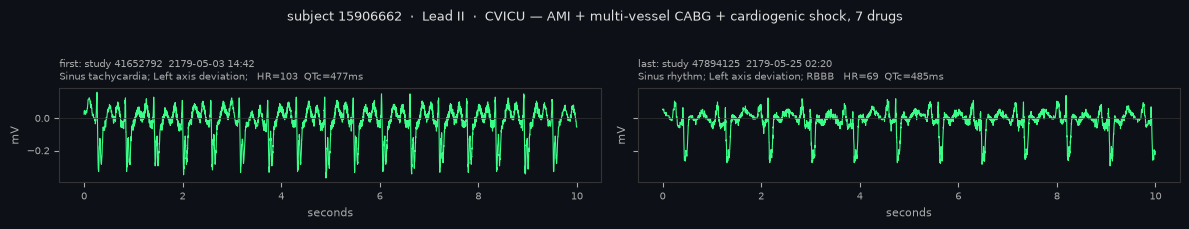

In [17]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

for patient in FINAL_PATIENTS:
    sid   = patient["subject_id"]
    label = patient["label"]
    entries = [e for e in all_results.get(sid, []) if e["extraction_ok"]]

    if not entries:
        print(f"⚠️  No successful extractions for subject {sid}")
        continue

    # Pick first and last
    to_plot = []
    if len(entries) >= 1: to_plot.append(("first", entries[0]))
    if len(entries) >= 2: to_plot.append(("last",  entries[-1]))

    n_plots = len(to_plot)
    fig, axes = plt.subplots(1, n_plots, figsize=(12, 2.2), sharey=True)
    if n_plots == 1: axes = [axes]
    fig.patch.set_facecolor("#0d1117")

    for ax, (timing, entry) in zip(axes, to_plot):
        sig = np.load(str(PROJECT_ROOT / entry["lead2_file"]))
        fs  = entry["fs"] or 500
        t   = np.arange(len(sig)) / fs  # seconds

        ax.set_facecolor("#0d1117")
        ax.plot(t, sig, color="#39ff88", lw=0.8)
        ax.axhline(0, color="#333", lw=0.5)

        # Annotate
        machine = entry.get("machine_rhythm") or ""
        hr_m    = entry.get("machine_hr")
        qtc_m   = entry.get("machine_qtc_ms")
        ann     = f"{machine[:40]}"
        if hr_m:  ann += f"  HR={hr_m:.0f}"
        if qtc_m: ann += f"  QTc={qtc_m:.0f}ms"

        ax.set_title(
            f"{timing}: study {entry['study_id']}  {str(entry['ecg_time'])[:16]}\n{ann}",
            color="#aaaaaa", fontsize=7.5, loc="left")
        ax.set_xlabel("seconds", color="#aaaaaa", fontsize=8)
        ax.set_ylabel("mV", color="#aaaaaa", fontsize=8)
        ax.tick_params(colors="#aaaaaa", labelsize=7)
        for spine in ax.spines.values(): spine.set_edgecolor("#333333")

    fig.suptitle(
        f"subject {sid}  ·  Lead II  ·  {label}",
        color="#e0e0e0", fontsize=9, y=1.02)
    plt.tight_layout()
    plt.show()
    print()


---
## Section 6 · Summary table + coverage check


In [18]:
rows = []
for patient in FINAL_PATIENTS:
    sid = patient["subject_id"]
    entries = all_results.get(sid, [])
    ok     = sum(1 for e in entries if e["extraction_ok"])
    failed = len(entries) - ok
    # Check that parquet ecg_lead2_file paths now resolve on disk
    parquet_path = TIMELINE_DIR / f"patient_{sid}.parquet"
    csv_path     = TIMELINE_DIR / f"patient_{sid}.csv"
    timeline_exists = parquet_path.exists() or csv_path.exists()

    rows.append({
        "subject_id":     sid,
        "label":          patient["label"][:50],
        "ecg_total":      len(entries),
        "extracted_ok":   ok,
        "failed":         failed,
        "waveforms_saved": ok * 2,  # lead2 + all12 per study
        "timeline_file":  "✅" if timeline_exists else "❌",
    })

summary = pd.DataFrame(rows)
print(summary.to_string(index=False))

print()
total_files = sum(r["waveforms_saved"] for r in rows)
print(f"Total .npy files saved: {total_files}")
print(f"Output directory: {WAVEFORM_DIR}")


 subject_id                                              label  ecg_total  extracted_ok  failed  waveforms_saved timeline_file
   16179553 CVICU — mitral valve replacement + ECMO + cardioge          7             7       0               14             ✅
   17520318         CVICU — CABG + AVR + septic shock, 7 drugs          7             7       0               14             ✅
   13269747             CCU — AFib under rate control, 16 ECGs         16            16       0               32             ✅
   13408370      CCU — anterior MI + VF arrest + AICD, 28 ECGs         28            28       0               56             ✅
   15906662 CVICU — AMI + multi-vessel CABG + cardiogenic shoc          8             8       0               16             ✅

Total .npy files saved: 132
Output directory: c:\Users\dalia\OneDrive\Dokumente\Praktikum2026\SASISimulator\data\processed\ecg_waveforms


---
## Done ✓

The waveform extraction is complete. The streaming engine can now load real Lead II
signals for all successfully extracted ECG records. For records where extraction failed,
the engine falls back to a synthetic Lead II generated from the charted heart rate.

```
data/processed/
├── ecg_waveforms/       .npy files — one per study × 2 (lead2 + all12)
└── ecg_index/           ecg_index_<subject_id>.json — one per patient
```

**Next:** build `src/engine/` — the simulation engine that replays these timelines and
waveforms as a continuous stream.


In [26]:
import pandas as pd, json
patient_timelines_dir = PROJECT_ROOT / "data" / "processed" / "patient_timelines"
df = pd.read_parquet(patient_timelines_dir / "patient_13269747.parquet")
print("troponin present:", "troponin" in df.columns,
      "| coverage:", round(df["troponin"].notna().mean(), 3) if "troponin" in df else 0)
print("ECG HR  range:", round(df["ecg_machine_hr"].min(),1), "-", round(df["ecg_machine_hr"].max(),1))
print("ECG QTc range:", round(df["ecg_machine_qtc_ms"].min(),1), "-", round(df["ecg_machine_qtc_ms"].max(),1))
print("rhythm sample:", df["ecg_machine_rhythm"].dropna().head(2).tolist())
print("QTc alarm fires anywhere:", bool(df["alarm_qtc_prolonged"].any()))
ECG_INDEX_DIR = PROJECT_ROOT / "data" / "processed" / "ecg_index"
idx = json.load(open(ECG_INDEX_DIR / "ecg_index_13269747.json"))
print("index machine_qtc_ms (first):", idx[0].get("machine_qtc_ms"))
print("index machine_rhythm (first):", idx[0].get("machine_rhythm"))

troponin present: True | coverage: 0.09
ECG HR  range: 65.0 - 158.3
ECG QTc range: 404.6 - 506.8
rhythm sample: ['Atrial fibrillation with rapid ventricular response with non-sustained ventricular tachycardia; Prolonged QT interval; Incomplete LBBB; LVH with secondary repolarization abnormality; Inferior/lateral ST-T changes may be due to hypertrophy and/or ischemia; Abnormal ECG', 'Atrial fibrillation with rapid ventricular response with non-sustained ventricular tachycardia; Prolonged QT interval; Incomplete LBBB; LVH with secondary repolarization abnormality; Inferior/lateral ST-T changes may be due to hypertrophy and/or ischemia; Abnormal ECG']
QTc alarm fires anywhere: True
index machine_qtc_ms (first): 506.71532112880374
index machine_rhythm (first): Atrial fibrillation with uncontrolled ventricular response; Indeterminate axis; IV conduction defect; Possible anterior infarct - age undetermined; Inferior/lateral ST-T changes may be due to myocardial ischemia; Abnormal ECG
